<a href="https://colab.research.google.com/github/Fatima-Tuj-Johara/Machine_Learning_Projects/blob/main/Cancer_Risk_Prediction_EDA/Cancer%20Risk%20Prediction%20EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [39]:
df=pd.read_csv("cancer-risk-factors.csv")

In [40]:
df.head(5)

,Patient_ID,Cancer_Type,Age,Gender,Smoking,Alcohol_Use,Obesity,Family_History,Diet_Red_Meat,Diet_Salted_Processed,...,Physical_Activity,Air_Pollution,Occupational_Hazards,BRCA_Mutation,H_Pylori_Infection,Calcium_Intake,Overall_Risk_Score,BMI,Physical_Activity_Level,Risk_Level
0,LU0000,Breast,68,0,7,2,8,0,5,3,...,4,6,3,1,0,0,0.398696,28.0,5,Medium
1,LU0001,Prostate,74,1,8,9,8,0,0,3,...,1,3,3,0,0,5,0.424299,25.4,9,Medium
2,LU0002,Skin,55,1,7,10,7,0,3,3,...,1,8,10,0,0,6,0.605082,28.6,2,Medium
3,LU0003,Colon,61,0,6,2,2,0,6,2,...,6,4,8,0,0,8,0.318449,32.1,7,Low
4,LU0004,Lung,67,1,10,7,4,0,6,3,...,9,10,9,0,0,5,0.524358,25.1,2,Medium


In [41]:
df.columns

Index(['Patient_ID', 'Cancer_Type', 'Age', 'Gender', 'Smoking', 'Alcohol_Use',
       'Obesity', 'Family_History', 'Diet_Red_Meat', 'Diet_Salted_Processed',
       'Fruit_Veg_Intake', 'Physical_Activity', 'Air_Pollution',
       'Occupational_Hazards', 'BRCA_Mutation', 'H_Pylori_Infection',
       'Calcium_Intake', 'Overall_Risk_Score', 'BMI',
       'Physical_Activity_Level', 'Risk_Level'],
      dtype='object')

## Indentification
- Patient ID -Unique ID for each patient
- Cancer Type - The type of cancer diagnosed

## General Characteristics
- Age
- Gender
- BMI - Body Mass Index

## Lifestyle & Environmental Factors
- Smoking
- Alcohol_use
- Obesity
- Diet_Red_Meat
- Diet_Salted_Processed
- Fruit_Veg_Intake
- Air_Pollution
- Occupational_Hazards
- Calcium_Intake

## Medical Factors
- Family History
- BRCA_Mutation
- H_Pylori_Infection

##Engineered (Calculated Features)
- Overall Risk Score
- Risk Level
## What To predict?
  Risk level



In [42]:
df.columns

Index(['Patient_ID', 'Cancer_Type', 'Age', 'Gender', 'Smoking', 'Alcohol_Use',
       'Obesity', 'Family_History', 'Diet_Red_Meat', 'Diet_Salted_Processed',
       'Fruit_Veg_Intake', 'Physical_Activity', 'Air_Pollution',
       'Occupational_Hazards', 'BRCA_Mutation', 'H_Pylori_Infection',
       'Calcium_Intake', 'Overall_Risk_Score', 'BMI',
       'Physical_Activity_Level', 'Risk_Level'],
      dtype='object')

In [43]:
df.Cancer_Type.value_counts()

,count
Cancer_Type,
Lung,527
Breast,460
Colon,418
Prostate,305
Skin,290


## Understanding The Dataset By EDA

In [44]:
risk_counts=df['Risk_Level'].value_counts()
print(risk_counts)

Risk_Level
Medium    1574
Low        324
High       102
Name: count, dtype: int64


In [45]:
df['Risk_Level'].value_counts()/len(df)*100

,count
Risk_Level,
Medium,78.7
Low,16.2
High,5.1


## The Data is highly imbalanced
- Low - 16.2%
- Medium - 78.7%
- High - 5.1%

In [46]:
df.Gender.value_counts()

,count
Gender,
0,1022
1,978


<Axes: xlabel='Cancer_Type'>

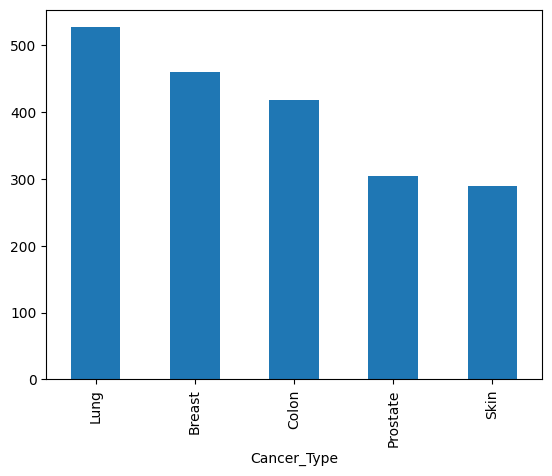

In [47]:
df.Cancer_Type.value_counts().plot(kind='bar')

In [48]:
gender_cancer_counts=df.groupby(['Gender', 'Cancer_Type']).size().reset_index(name='Patient_count')

In [49]:
gender_cancer_counts['Gender']=gender_cancer_counts['Gender'].map({0:'Female', 1:'Male'})
print(gender_cancer_counts)

   Gender Cancer_Type  Patient_count
0  Female      Breast            455
1  Female       Colon            197
2  Female        Lung            238
3  Female        Skin            132
4    Male      Breast              5
5    Male       Colon            221
6    Male        Lung            289
7    Male    Prostate            305
8    Male        Skin            158


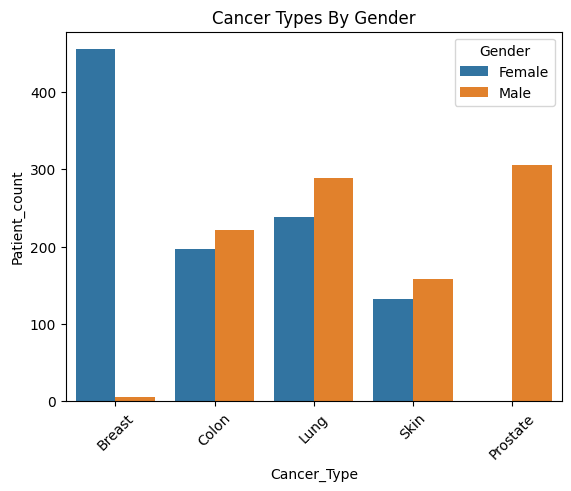

In [50]:
sns.barplot(data=gender_cancer_counts, x='Cancer_Type', y='Patient_count', hue='Gender')
plt.title("Cancer Types By Gender")
plt.xticks(rotation=45)
plt.show()

In [51]:
#Find all patients under 35
young_patients=df[df['Age']<35].reset_index(drop=True)
young_patients

,Patient_ID,Cancer_Type,Age,Gender,Smoking,Alcohol_Use,Obesity,Family_History,Diet_Red_Meat,Diet_Salted_Processed,...,Physical_Activity,Air_Pollution,Occupational_Hazards,BRCA_Mutation,H_Pylori_Infection,Calcium_Intake,Overall_Risk_Score,BMI,Physical_Activity_Level,Risk_Level
0,BR0020,Skin,32,0,1,3,8,0,5,1,...,0,4,4,0,0,3,0.283988,34.2,1,Low
1,BR0033,Lung,25,0,8,6,5,0,3,5,...,5,8,9,0,0,3,0.550154,28.9,8,Medium
2,BR0054,Lung,29,0,8,6,7,0,3,0,...,0,7,2,0,0,2,0.412898,23.9,6,Medium
3,BR0068,Lung,32,0,8,2,0,0,1,9,...,0,8,2,0,0,2,0.338060,23.9,2,Medium
4,BR0095,Breast,31,0,1,9,10,0,8,5,...,4,0,4,0,0,0,0.421680,28.2,6,Medium
5,BR0185,Lung,34,0,6,8,5,0,3,1,...,3,8,4,0,1,2,0.516405,27.0,3,Medium
6,BR0193,Breast,34,0,5,1,10,1,1,8,...,5,4,5,1,0,4,0.468496,27.3,0,Medium
7,BR0221,Lung,25,0,7,10,6,0,2,7,...,4,7,10,0,0,0,0.583443,27.9,4,Medium
8,BR0298,Lung,34,0,8,0,2,0,0,0,...,1,7,5,0,1,1,0.246356,29.7,9,Low


In [52]:
count_young=(df['Age']<35).sum()
print(f"Number of patients under 35: {count_young}")

Number of patients under 35: 9


In [53]:
young_cancer_types=df[df['Age']<35]['Cancer_Type'].value_counts()
young_cancer_types

,count
Cancer_Type,
Lung,6
Breast,2
Skin,1


In [54]:
## Finding out which factors highly contribute to high risk level
#Select only Numeric Columns
numeric_columns=df.select_dtypes(include='number').columns
numeric_columns

Index(['Age', 'Gender', 'Smoking', 'Alcohol_Use', 'Obesity', 'Family_History',
       'Diet_Red_Meat', 'Diet_Salted_Processed', 'Fruit_Veg_Intake',
       'Physical_Activity', 'Air_Pollution', 'Occupational_Hazards',
       'BRCA_Mutation', 'H_Pylori_Infection', 'Calcium_Intake',
       'Overall_Risk_Score', 'BMI', 'Physical_Activity_Level'],
      dtype='object')

In [55]:
#Compute the mean of each numeric feature per risk level
risk_means = df.groupby('Risk_Level')[numeric_columns].mean().transpose()
risk_means

Risk_Level,High,Low,Medium
Age,63.745098,63.685185,63.125794
Gender,0.509804,0.493827,0.486658
Smoking,7.519608,2.845679,5.479670
Alcohol_Use,7.519608,2.984568,5.296061
Obesity,7.274510,4.824074,6.118170
Family_History,0.205882,0.138889,0.205210
Diet_Red_Meat,7.362745,3.972222,5.299238
Diet_Salted_Processed,7.039216,2.888889,4.747776
Fruit_Veg_Intake,3.911765,5.666667,4.841169
Physical_Activity,4.921569,3.669753,4.027319


# Insights
- Air Pollution:    Strongest indicator significantly higher in High Risk patients.

- Smoking & Alcohol: Both heavily correlate with high cancer risk.

- Diet (Red Meat & Processed Foods): High intake directly drives up risk levels.

- Diet (Fruits & Vegetables): Only factor that lowers risk.

- Occupational Hazards & Obesity: Clear differentiators separating high risk from low risk.

- Age, Gender & BMI: Show almost no impact on risk levels in this dataset.

In [56]:
#Focus on difference between High and Low Risk
risk_diff=risk_means['High']-risk_means['Low']
risk_diff=risk_diff.sort_values(ascending=False)
risk_diff


,0
Air_Pollution,5.591685
Smoking,4.673929
Alcohol_Use,4.535040
Diet_Salted_Processed,4.150327
Occupational_Hazards,3.625999
Diet_Red_Meat,3.390523
Obesity,2.450436
Physical_Activity,1.251816
Calcium_Intake,0.672295
Overall_Risk_Score,0.430533


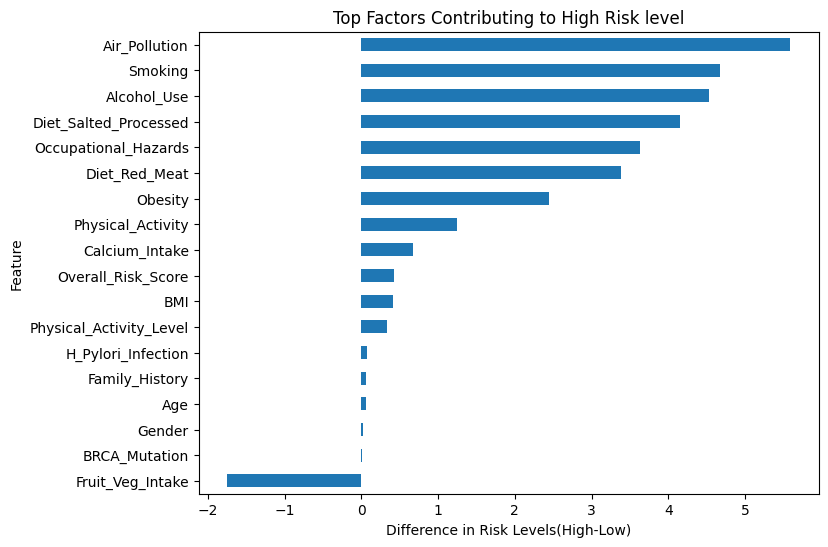

In [57]:
risk_diff.sort_values(ascending=True).plot(kind='barh',figsize=(8,6),title='Top Factors Contributing to High Risk level')
plt.xlabel('Difference in Risk Levels(High-Low)')
plt.ylabel('Feature')
plt.show()

## Air polution, Smoking, Alchohol use top 3 contributing factors in high risk level

In [58]:
df.head(1)

,Patient_ID,Cancer_Type,Age,Gender,Smoking,Alcohol_Use,Obesity,Family_History,Diet_Red_Meat,Diet_Salted_Processed,...,Physical_Activity,Air_Pollution,Occupational_Hazards,BRCA_Mutation,H_Pylori_Infection,Calcium_Intake,Overall_Risk_Score,BMI,Physical_Activity_Level,Risk_Level
0,LU0000,Breast,68,0,7,2,8,0,5,3,...,4,6,3,1,0,0,0.398696,28.0,5,Medium


## Univariate Analysis

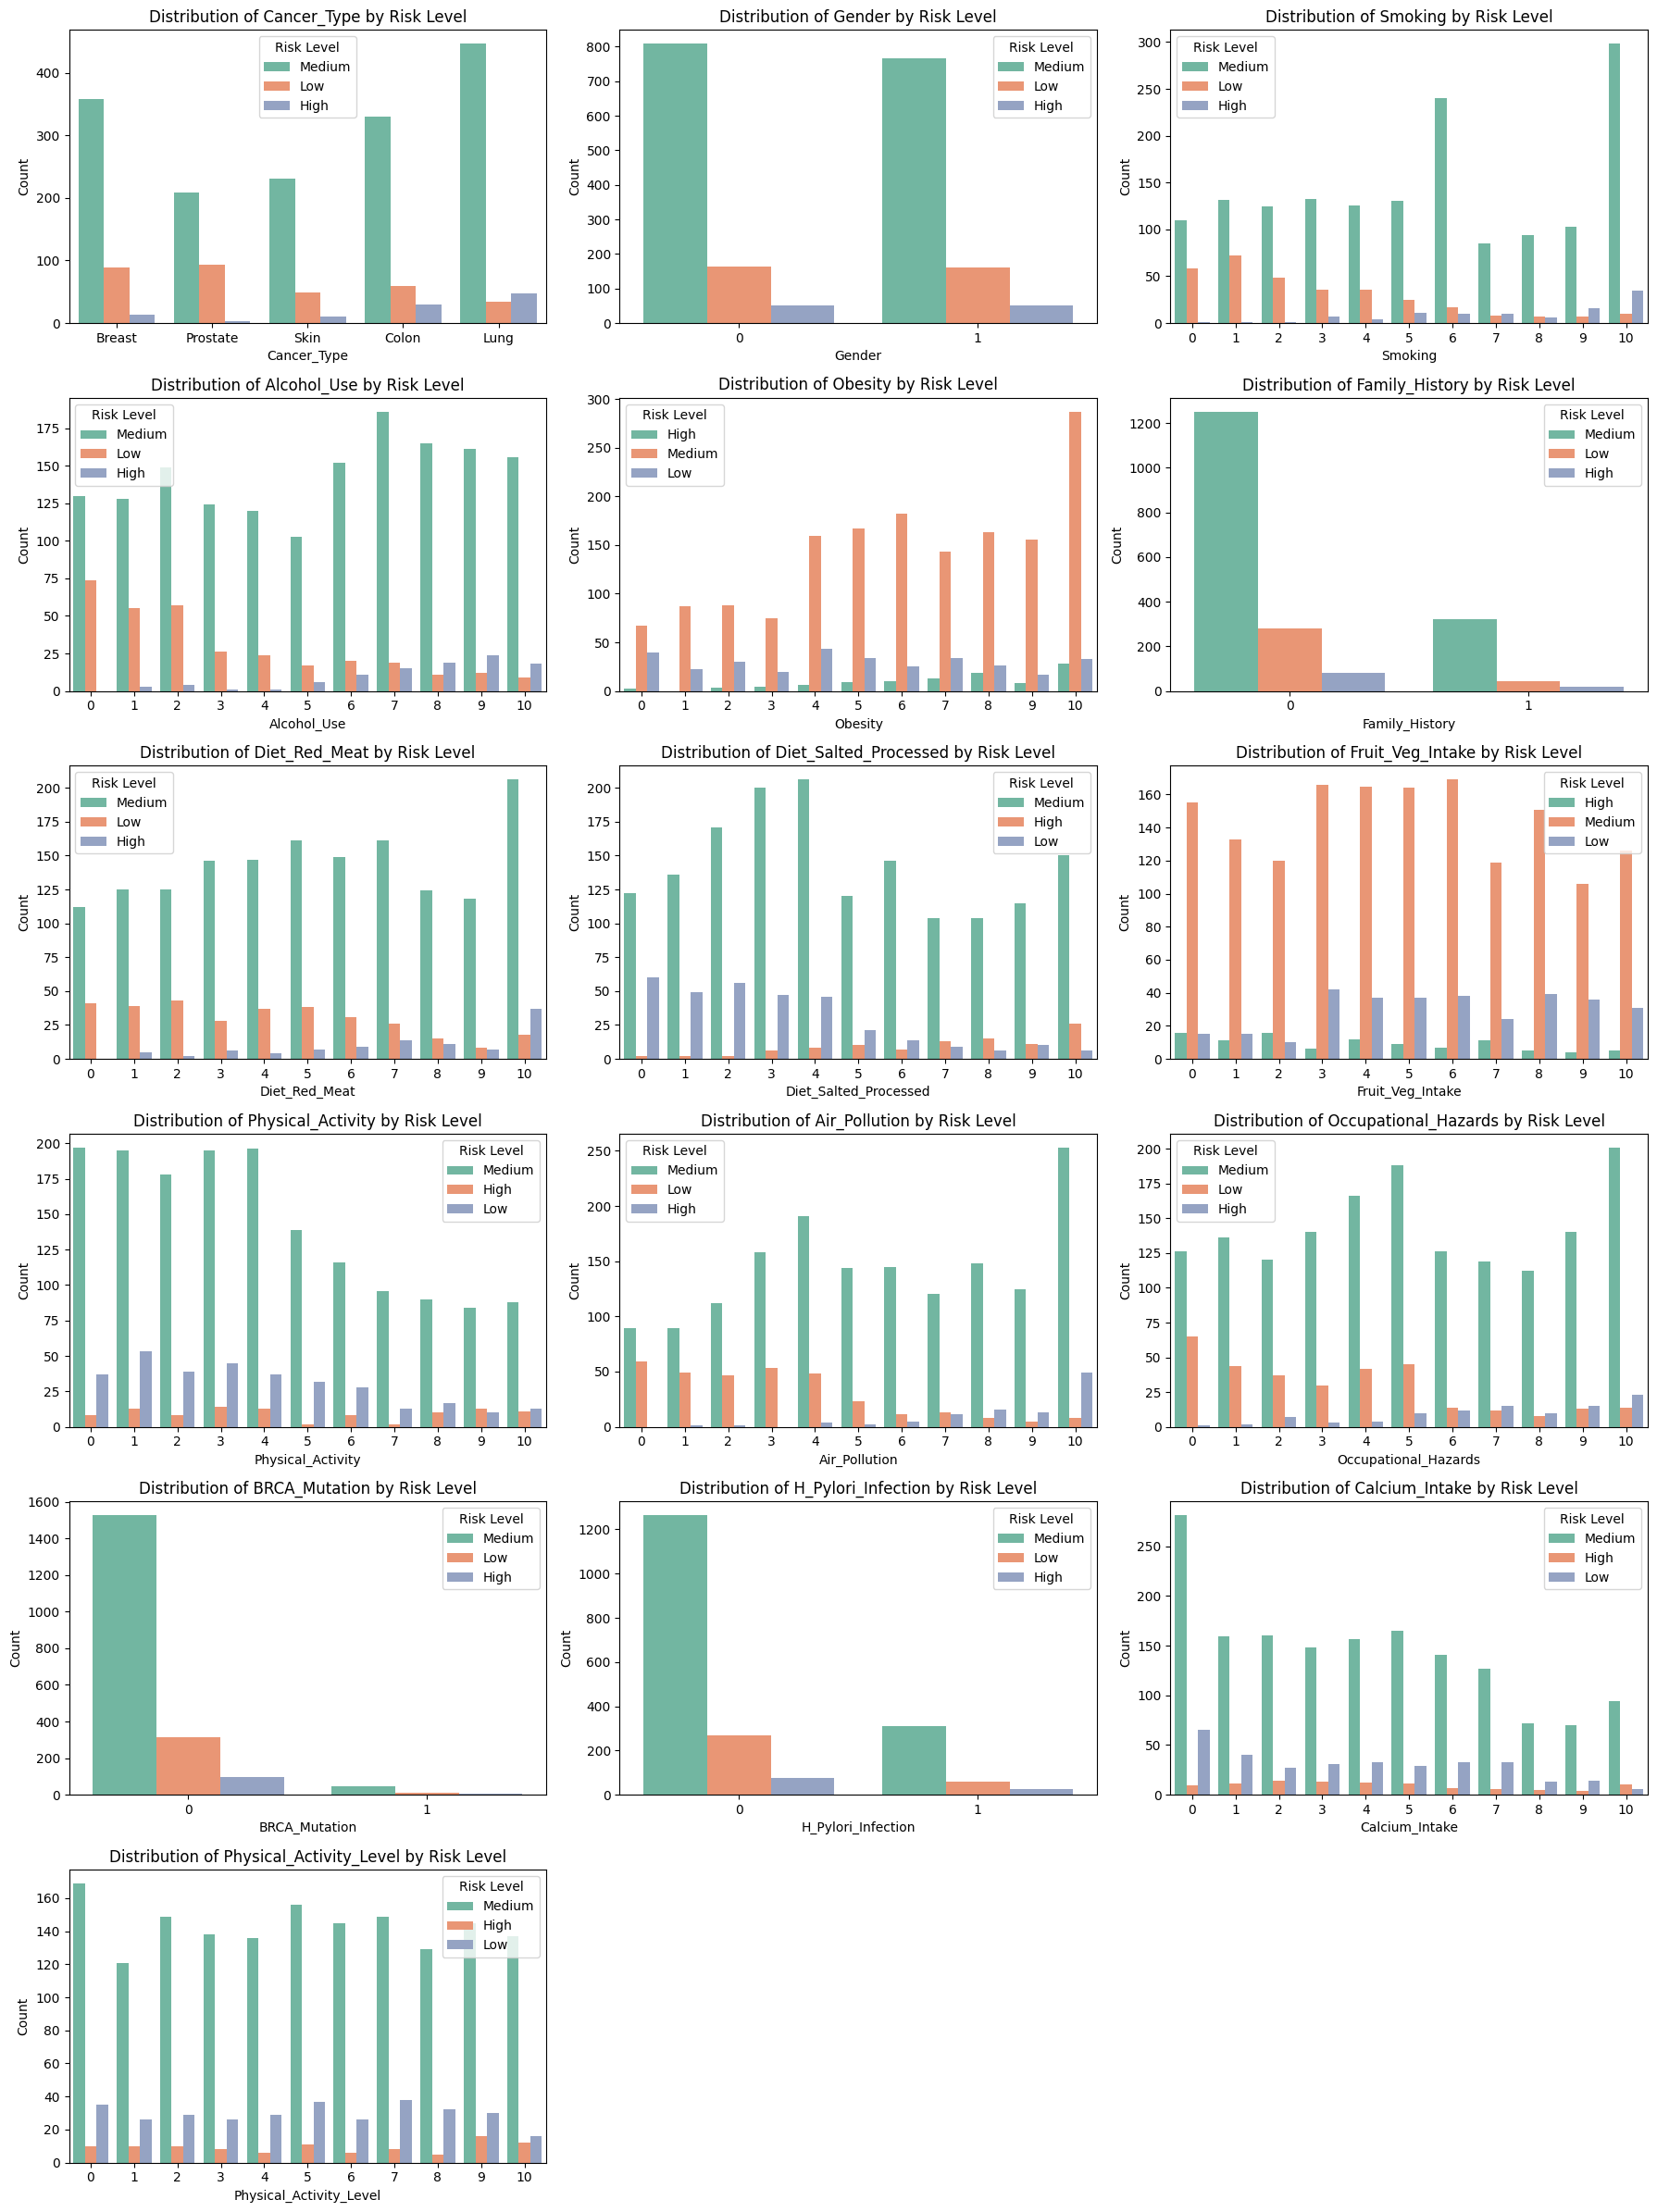

In [59]:
predictors = df.drop(columns=['Patient_ID', 'Risk_Level', 'Age', 'Overall_Risk_Score', 'BMI']).columns

plt.figure(figsize=(18, 24))

for i, predictor in enumerate(predictors):
    plt.subplot(6, 3, i + 1)
    sns.countplot(data=df, x=predictor, hue='Risk_Level', palette='Set2')
    plt.title(f'Distribution of {predictor} by Risk Level')
    plt.xlabel(predictor)
    plt.ylabel('Count')
    plt.legend(title='Risk Level')

plt.tight_layout()
plt.show()

In [60]:
df = df.drop(columns=['Patient_ID'])
df['Risk_Level'] = df['Risk_Level'].replace({'Low': 0, 'Medium': 1, 'High': 2})

df.head(2)

/tmp/ipykernel_1357/558841133.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Risk_Level'] = df['Risk_Level'].replace({'Low': 0, 'Medium': 1, 'High': 2})


,Cancer_Type,Age,Gender,Smoking,Alcohol_Use,Obesity,Family_History,Diet_Red_Meat,Diet_Salted_Processed,Fruit_Veg_Intake,Physical_Activity,Air_Pollution,Occupational_Hazards,BRCA_Mutation,H_Pylori_Infection,Calcium_Intake,Overall_Risk_Score,BMI,Physical_Activity_Level,Risk_Level
0,Breast,68,0,7,2,8,0,5,3,7,4,6,3,1,0,0,0.398696,28.0,5,1
1,Prostate,74,1,8,9,8,0,0,3,7,1,3,3,0,0,5,0.424299,25.4,9,1


In [64]:
df.head(2)

,Cancer_Type,Age,Gender,Smoking,Alcohol_Use,Obesity,Family_History,Diet_Red_Meat,Diet_Salted_Processed,Fruit_Veg_Intake,Physical_Activity,Air_Pollution,Occupational_Hazards,BRCA_Mutation,H_Pylori_Infection,Calcium_Intake,Overall_Risk_Score,BMI,Physical_Activity_Level,Risk_Level
0,Breast,68,0,7,2,8,0,5,3,7,4,6,3,1,0,0,0.398696,28.0,5,1
1,Prostate,74,1,8,9,8,0,0,3,7,1,3,3,0,0,5,0.424299,25.4,9,1


In [65]:
df_dummies=pd.get_dummies(df)
df_dummies.head(2)

,Age,Gender,Smoking,Alcohol_Use,Obesity,Family_History,Diet_Red_Meat,Diet_Salted_Processed,Fruit_Veg_Intake,Physical_Activity,...,Calcium_Intake,Overall_Risk_Score,BMI,Physical_Activity_Level,Risk_Level,Cancer_Type_Breast,Cancer_Type_Colon,Cancer_Type_Lung,Cancer_Type_Prostate,Cancer_Type_Skin
0,68,0,7,2,8,0,5,3,7,4,...,0,0.398696,28.0,5,1,True,False,False,False,False
1,74,1,8,9,8,0,0,3,7,1,...,5,0.424299,25.4,9,1,False,False,False,True,False


<Axes: >

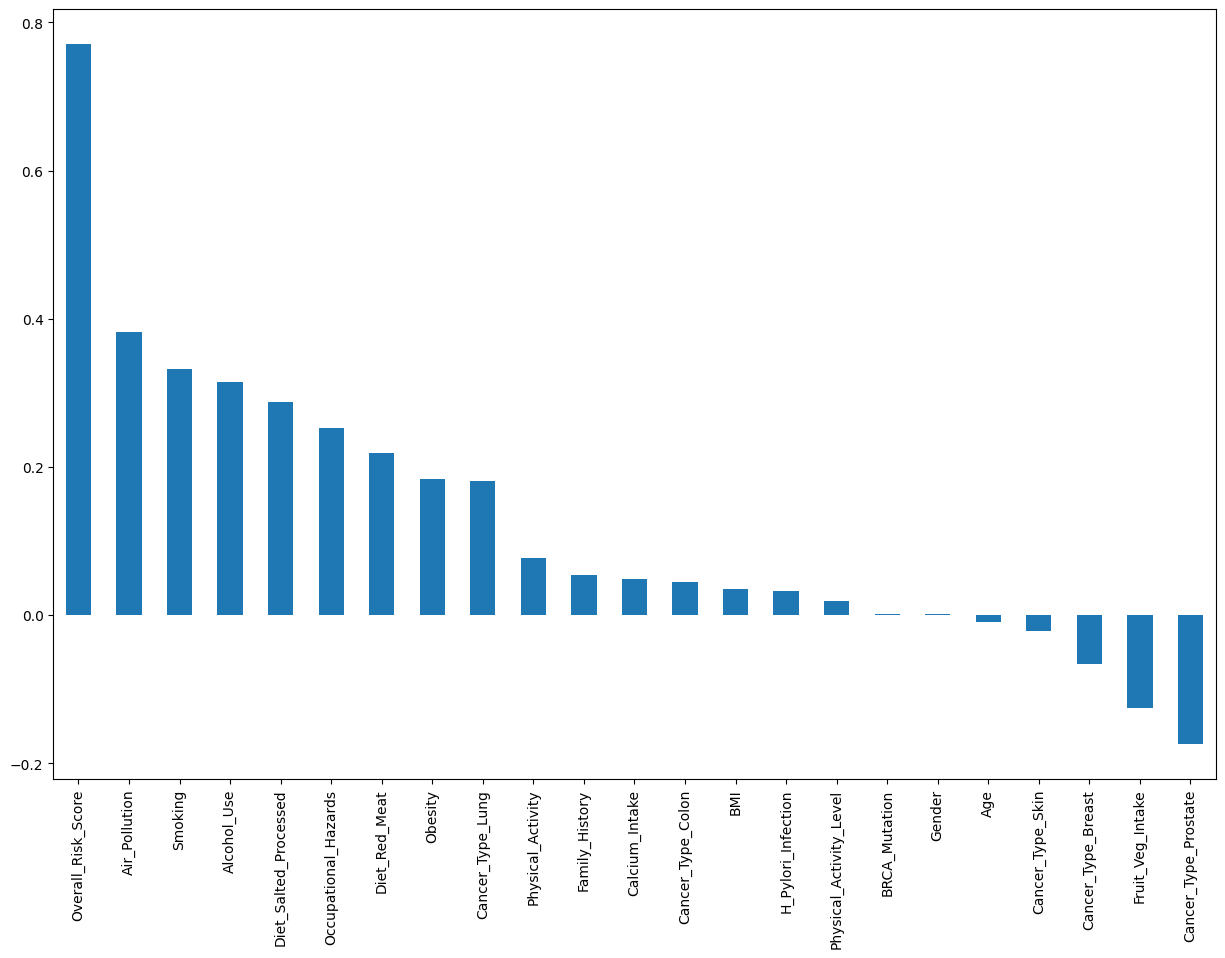

In [67]:
plt.figure(figsize=(15,10))
df_dummies.corr()['Risk_Level'].sort_values(ascending=False).drop('Risk_Level').plot(kind='bar')